Подготовка окружения (ячейка Colab)

In [1]:
# Установки (если нужно)
!pip -q install kagglehub

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


1) BanknoteAuthentication: загрузка данных (ячейка Colab)

In [2]:
import kagglehub

path = kagglehub.dataset_download("ritesaluja/bank-note-authentication-uci-data")
print("Dataset path:", path)

df_banknote = pd.read_csv(f"{path}/BankNote_Authentication.csv")
df_banknote.head()


100%|██████████| 19.2k/19.2k [00:00<00:00, 30.4MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/ritesaluja/bank-note-authentication-uci-data/versions/1


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
df_banknote.info()
df_banknote["class"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


,count
class,
0,762
1,610


Banknote: правильное разбиение

In [4]:
df0 = df_banknote[df_banknote["class"] == 0]
df1 = df_banknote[df_banknote["class"] == 1]

test0 = df0.tail(107)
test1 = df1.tail(119)
df_test = pd.concat([test0, test1], axis=0)

# train = всё остальное
df_train = df_banknote.drop(df_test.index)

Xb_train = df_train.drop(columns=["class"])
yb_train = df_train["class"].astype(int)

Xb_test = df_test.drop(columns=["class"])
yb_test = df_test["class"].astype(int)

print("Train size:", len(df_train), "Test size:", len(df_test))
print("Test class counts:\n", df_test["class"].value_counts())


Train size: 1146 Test size: 226
Test class counts:
 class
1    119
0    107
Name: count, dtype: int64


3) Banknote: Pipeline + GridSearchCV на разные ядра

In [19]:

import pandas as pd

banknote_gs_fast.fit(Xb_train, yb_train)

results = pd.DataFrame(banknote_gs_fast.cv_results_)

# ДОБАВЬ ЭТУ СТРОКУ
results["kernel"] = results["param_svc__kernel"].astype(str)

best_by_kernel = (
    results.groupby("kernel")["mean_test_score"]
    .max()
    .sort_values(ascending=False)
)

print("=== Best CV accuracy by kernel ===")
for k, acc in best_by_kernel.items():
    print(f"{k:>6}: {acc:.4f}")

print("\n=== Best params per kernel ===")
for k in best_by_kernel.index:
    sub = results[results["kernel"] == k].copy()
    best_row = sub.loc[sub["mean_test_score"].idxmax()]
    print(f"{k:>6}: acc={best_row['mean_test_score']:.4f}, params={best_row['params']}")



Fitting 5 folds for each of 13 candidates, totalling 65 fits
=== Best CV accuracy by kernel ===
   rbf: 1.0000
  poly: 0.9930
linear: 0.9913

=== Best params per kernel ===
   rbf: acc=1.0000, params={'svc__C': 1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
  poly: acc=0.9930, params={'svc__C': 10, 'svc__degree': 3, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}
linear: acc=0.9913, params={'svc__C': 10, 'svc__kernel': 'linear'}


4. Banknote: проверка на тесте + матрица ошибок

In [8]:
yb_pred = banknote_gs_fast.predict(Xb_test)

print("Test accuracy:", accuracy_score(yb_test, yb_pred))
print("Confusion matrix:\n", confusion_matrix(yb_test, yb_pred))
print("Report:\n", classification_report(yb_test, yb_pred, digits=4))



Test accuracy: 1.0
Confusion matrix:
 [[107   0]
 [  0 119]]
Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       107
           1     1.0000    1.0000    1.0000       119

    accuracy                         1.0000       226
   macro avg     1.0000    1.0000    1.0000       226
weighted avg     1.0000    1.0000    1.0000       226



5. AdultIncome: загрузка данных (ячейка Colab)

In [9]:
path_adult = kagglehub.dataset_download("wenruliu/adult-income-dataset")
print("Dataset path:", path_adult)

df_adult = pd.read_csv(f"{path_adult}/adult.csv")
df_adult.head()


100%|██████████| 652k/652k [00:00<00:00, 767kB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/wenruliu/adult-income-dataset/versions/2


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [10]:
df_adult.info()
df_adult["income"].value_counts(dropna=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,count
income,
<=50K,37155
>50K,11687


6. Adult: подготовка X/y и разбиение

In [11]:
df_adult_clean = df_adult.dropna().copy()

y_a = (df_adult_clean["income"].astype(str).str.contains(">50K", regex=False)).astype(int)
X_a = df_adult_clean.drop(columns=["income"])

Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42, stratify=y_a
)

print("Train:", Xa_train.shape, "Test:", Xa_test.shape)


Train: (39073, 14) Test: (9769, 14)


7. Adult: ColumnTransformer + Pipeline

In [12]:
num_cols = Xa_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in Xa_train.columns if c not in num_cols]

adult_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

adult_pipe = Pipeline(steps=[
    ("prep", adult_preprocess),
    ("svc", SVC())
])


Baseline для Adult

In [15]:
baseline_adult = adult_pipe.set_params(svc__kernel="rbf", svc__C=1, svc__gamma="scale")
baseline_adult.fit(Xa_train, ya_train)
base_pred = baseline_adult.predict(Xa_test)
print("Baseline test accuracy:", accuracy_score(ya_test, base_pred))


Baseline test accuracy: 0.8613983007472618


8. Adult: GridSearchCV (важно — делаем ускорение правильно)

In [13]:
SAMPLE_FOR_SEARCH = 10000

if SAMPLE_FOR_SEARCH < len(Xa_train):
    Xa_search, _, ya_search, _ = train_test_split(
        Xa_train, ya_train,
        train_size=SAMPLE_FOR_SEARCH,
        random_state=42,
        stratify=ya_train
    )
else:
    Xa_search, ya_search = Xa_train, ya_train

adult_param_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.1, 1, 10, 100]},
    {"svc__kernel": ["rbf"],
     "svc__C": [0.1, 1, 10, 100],
     "svc__gamma": ["scale", "auto", 0.1, 0.01, 0.001]},
    {"svc__kernel": ["poly"],
     "svc__C": [0.1, 1, 10],
     "svc__gamma": ["scale", "auto", 0.1, 0.01],
     "svc__degree": [2, 3],
     "svc__coef0": [0.0, 1.0]},
]

adult_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

adult_gs = GridSearchCV(
    estimator=adult_pipe,
    param_grid=adult_param_grid,
    scoring="accuracy",
    cv=adult_cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

adult_gs.fit(Xa_search, ya_search)

print("Best params:", adult_gs.best_params_)
print("Best CV accuracy (subset):", adult_gs.best_score_)


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params: {'svc__C': 10, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}
Best CV accuracy (subset): 0.8549006370343092


Adult: refit на полном train и оценка на тесте (ячейка Colab)

In [14]:
best_adult_model = adult_gs.best_estimator_
best_adult_model.fit(Xa_train, ya_train)

ya_pred = best_adult_model.predict(Xa_test)

print("Test accuracy:", accuracy_score(ya_test, ya_pred))
print("Confusion matrix:\n", confusion_matrix(ya_test, ya_pred))
print("Report:\n", classification_report(ya_test, ya_pred, digits=4))


Test accuracy: 0.8582249974408844
Confusion matrix:
 [[7014  417]
 [ 968 1370]]
Report:
               precision    recall  f1-score   support

           0     0.8787    0.9439    0.9101      7431
           1     0.7666    0.5860    0.6642      2338

    accuracy                         0.8582      9769
   macro avg     0.8227    0.7649    0.7872      9769
weighted avg     0.8519    0.8582    0.8513      9769



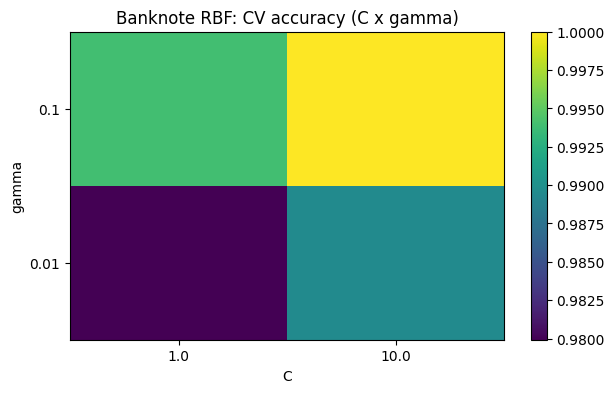

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_heatmap_from_gridsearch(gs, kernel="rbf", title="Heatmap"):
    # Берём результаты
    results = pd.DataFrame(gs.cv_results_)

    # Фильтруем только нужное ядро
    mask = results["param_svc__kernel"].astype(str) == kernel
    r = results[mask].copy()

    # Если параметров нет (например, gamma не в сетке), выйдем
    if "param_svc__C" not in r or ("param_svc__gamma" not in r and kernel == "rbf"):
        print("Нет нужных параметров в cv_results_ для heatmap.")
        return

    r["C"] = r["param_svc__C"].astype(float)
    r["gamma"] = r["param_svc__gamma"].astype(str)  # gamma может быть 'scale'
    r["mean_acc"] = r["mean_test_score"].astype(float)

    # Heatmap удобнее, когда gamma числовая — возьмём только числовые gamma
    r_num = r[r["gamma"].str.replace(".", "", 1).str.isdigit()].copy()
    if r_num.empty:
        print("В сетке нет числовых gamma (только 'scale/auto') — heatmap по gamma построить нельзя.")
        return

    r_num["gamma"] = r_num["gamma"].astype(float)

    pivot = r_num.pivot_table(index="gamma", columns="C", values="mean_acc", aggfunc="mean")
    pivot = pivot.sort_index(ascending=False)

    plt.figure(figsize=(7, 4))
    plt.imshow(pivot.values, aspect="auto")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.colorbar()
    plt.xlabel("C")
    plt.ylabel("gamma")
    plt.title(title)
    plt.show()

# Для твоего banknote_gs_fast (если там есть числовые gamma)
plot_heatmap_from_gridsearch(banknote_gs_fast, kernel="rbf", title="Banknote RBF: CV accuracy (C x gamma)")


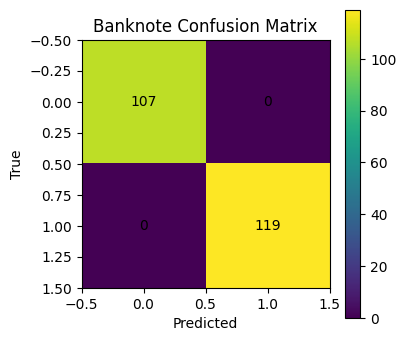

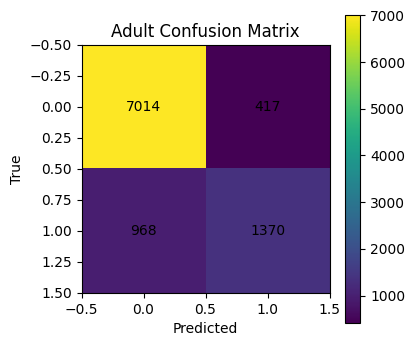

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, aspect="equal")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.show()

plot_conf_matrix(yb_test, yb_pred, title="Banknote Confusion Matrix")
plot_conf_matrix(ya_test, ya_pred, title="Adult Confusion Matrix")
